In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
file_name = "/content/mtsamples.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
eda_folder = "/content/eda_diagrams"
os.makedirs(eda_folder, exist_ok=True)

print("EDA folder created:", eda_folder)

EDA folder created: /content/eda_diagrams


In [ ]:
print("========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== FIRST 5 RECORDS ==========")
display(df.head())

print("\n========== STATISTICAL SUMMARY ==========")
display(df.describe(include="all"))

========== DATASET SHAPE ==========
(4999, 6)

========== COLUMN NAMES ==========
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

========== DATA TYPES ==========
Unnamed: 0            int64
description          object
medical_specialty    object
sample_name          object
transcription        object
keywords             object
dtype: object

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB

========== FIRST 5 RECORDS ==

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."



========== STATISTICAL SUMMARY ==========


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
count,4999.000000,4999,4999,4999,4966,3931
unique,NaN,2348,40,2377,2357,3849
top,NaN,An example/template for a routine normal male...,Surgery,Lumbar Discogram,"PREOPERATIVE DIAGNOSIS: , Low back pain.,POSTO...",
freq,NaN,12,1103,5,5,81
mean,2499.000000,NaN,NaN,NaN,NaN,NaN
std,1443.231328,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN
25%,1249.500000,NaN,NaN,NaN,NaN,NaN
50%,2499.000000,NaN,NaN,NaN,NaN,NaN
75%,3748.500000,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


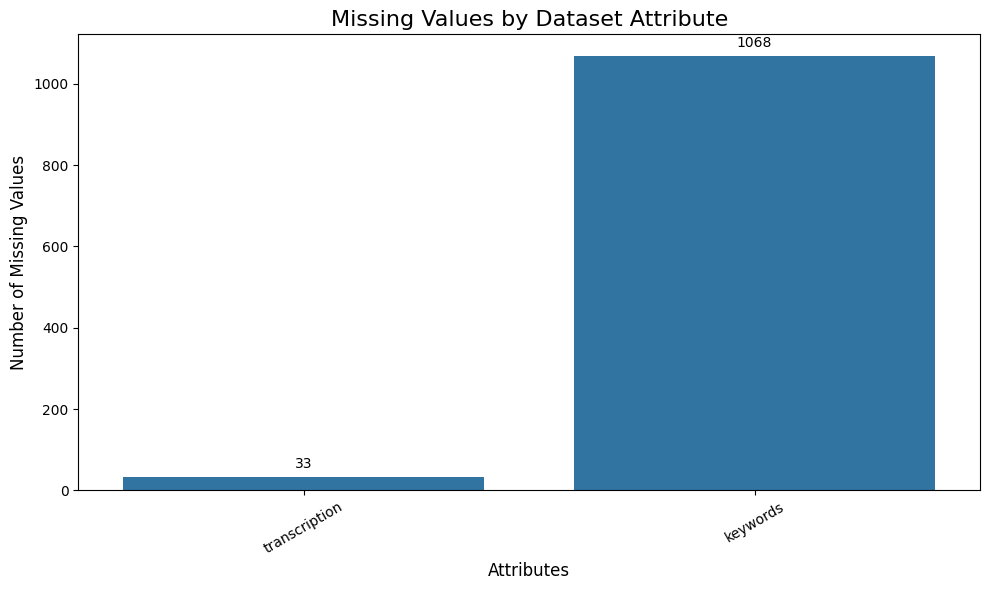

In [ ]:
plt.figure(figsize=(10, 6))

missing_plot = missing_values[missing_values > 0]

if len(missing_plot) > 0:
    ax = sns.barplot(
        x=missing_plot.index,
        y=missing_plot.values
    )

    plt.title("Missing Values by Dataset Attribute", fontsize=16)
    plt.xlabel("Attributes", fontsize=12)
    plt.ylabel("Number of Missing Values", fontsize=12)
    plt.xticks(rotation=30)

    for i, value in enumerate(missing_plot.values):
        ax.text(i, value + max(missing_plot.values) * 0.02,
                str(value), ha="center")

    plt.tight_layout()

    plt.savefig(
        f"{eda_folder}/01_missing_values.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
else:
    print("No missing values found.")

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [ ]:
specialty_counts = df["medical_specialty"].value_counts()

print("Number of unique medical specialties:",
      df["medical_specialty"].nunique())

display(specialty_counts)

Number of unique medical specialties: 40


,count
medical_specialty,
Surgery,1103
Consult - History and Phy.,516
Cardiovascular / Pulmonary,372
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,230
Neurology,223
SOAP / Chart / Progress Notes,166


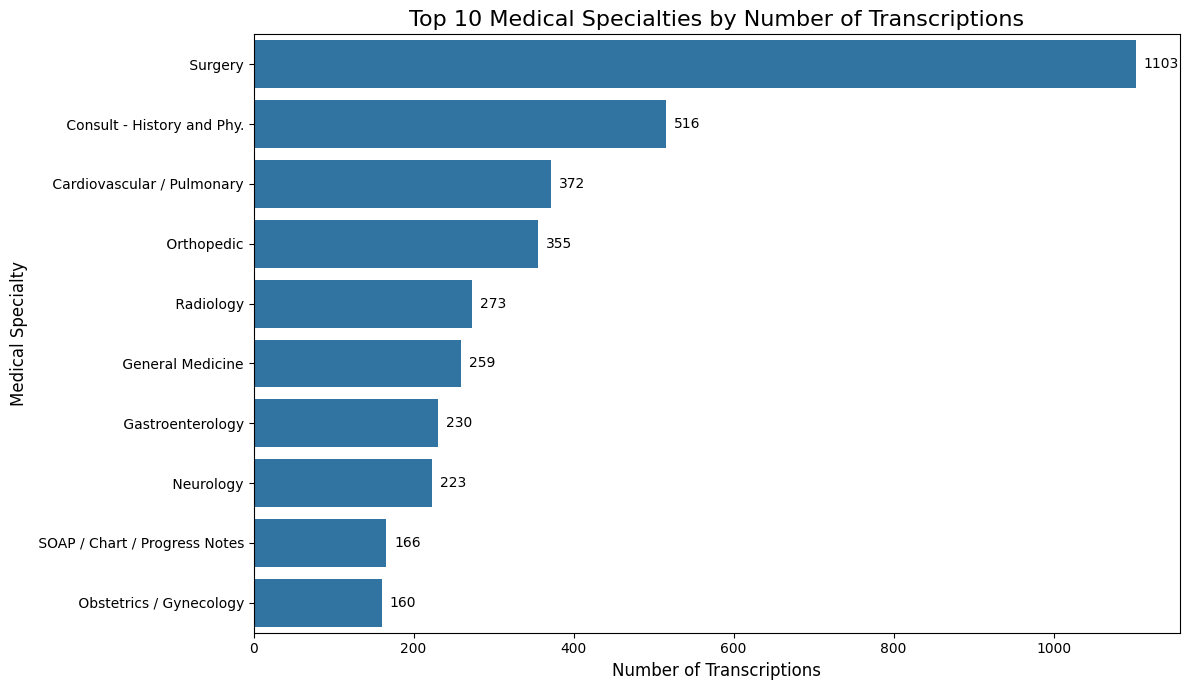

In [ ]:
top10 = specialty_counts.head(10)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Medical Specialties by Number of Transcriptions",
          fontsize=16)
plt.xlabel("Number of Transcriptions", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)

for i, value in enumerate(top10.values):
    ax.text(
        value + 10,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/02_top10_medical_specialties.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

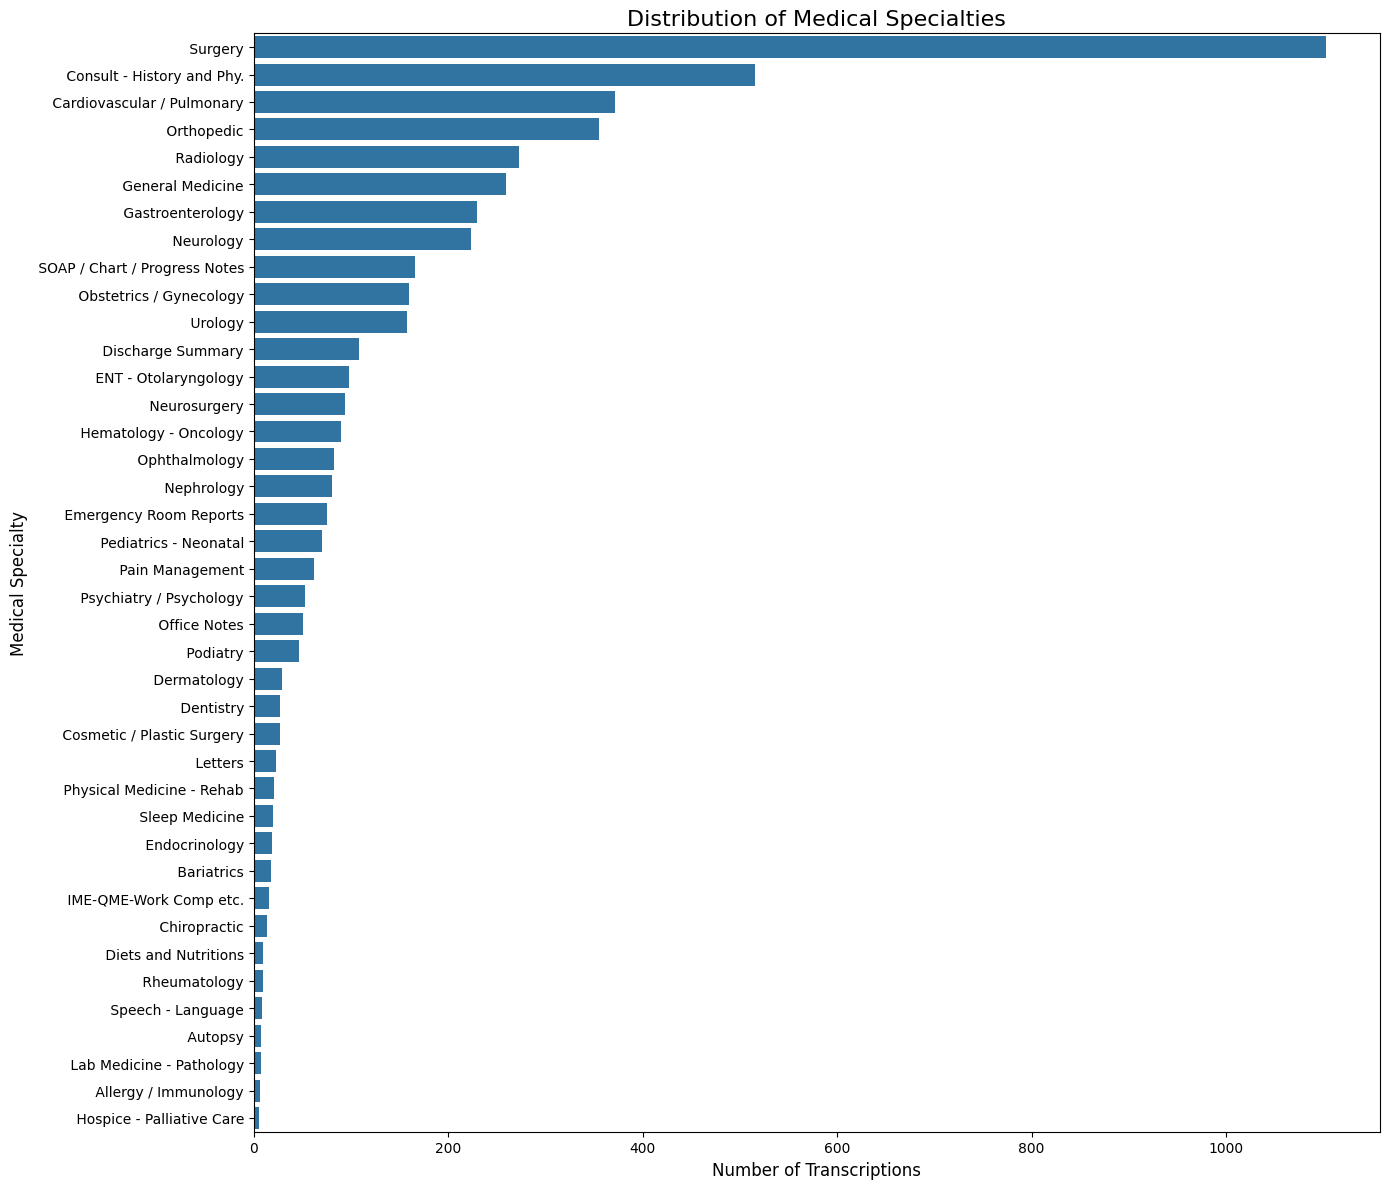

In [ ]:
plt.figure(figsize=(14, 12))

ax = sns.barplot(
    x=specialty_counts.values,
    y=specialty_counts.index
)

plt.title("Distribution of Medical Specialties",
          fontsize=16)

plt.xlabel("Number of Transcriptions", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/03_complete_specialty_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
df["transcription_length"] = (
    df["transcription"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print(df["transcription_length"].describe())

count    4999.000000
mean      462.376275
std       317.585206
min         0.000000
25%       239.000000
50%       397.000000
75%       614.000000
max      3029.000000
Name: transcription_length, dtype: float64


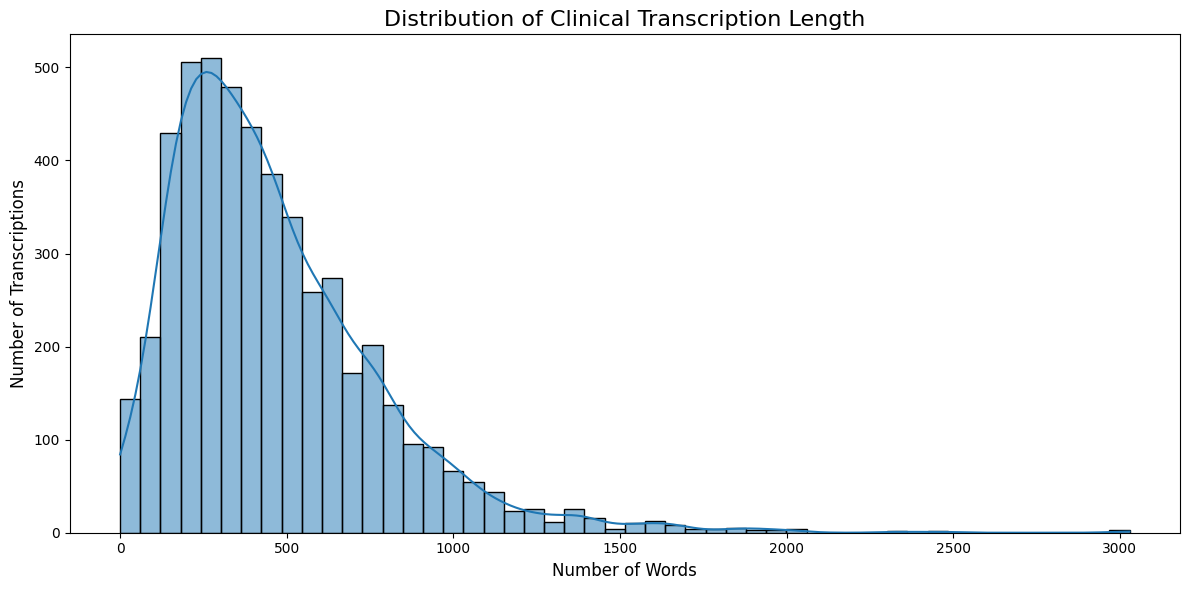

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["transcription_length"],
    bins=50,
    kde=True
)

plt.title("Distribution of Clinical Transcription Length",
          fontsize=16)

plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Number of Transcriptions", fontsize=12)

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/04_transcription_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

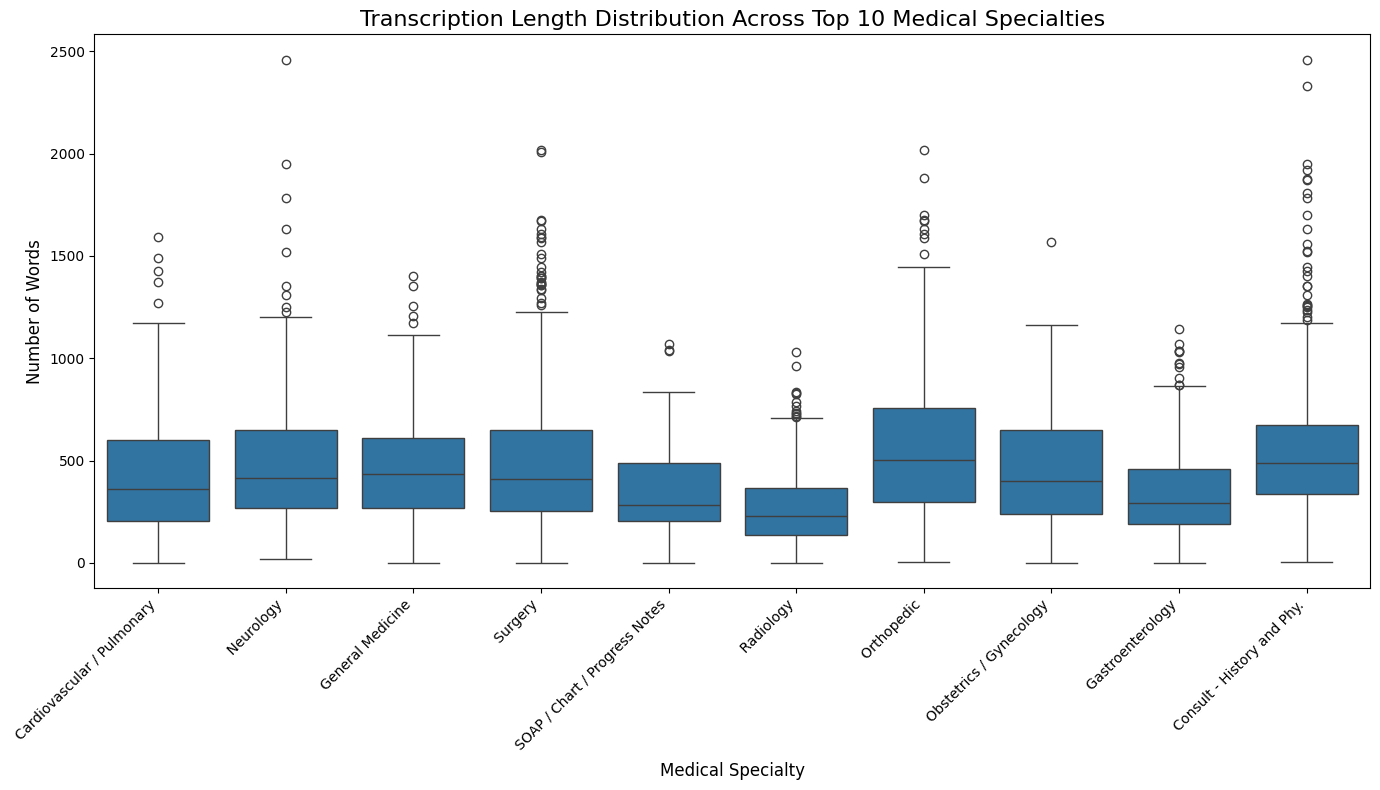

In [ ]:
top_specialties = specialty_counts.head(10).index

plot_df = df[
    df["medical_specialty"].isin(top_specialties)
].copy()

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=plot_df,
    x="medical_specialty",
    y="transcription_length"
)

plt.title("Transcription Length Distribution Across Top 10 Medical Specialties",
          fontsize=16)

plt.xlabel("Medical Specialty", fontsize=12)
plt.ylabel("Number of Words", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/05_transcription_length_by_specialty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!pip install wordcloud -q

In [ ]:
from wordcloud import WordCloud, STOPWORDS

text_data = df["transcription"].dropna().astype(str)

all_text = " ".join(text_data)

print("Total characters used for word cloud:", len(all_text))

Total characters used for word cloud: 15162758


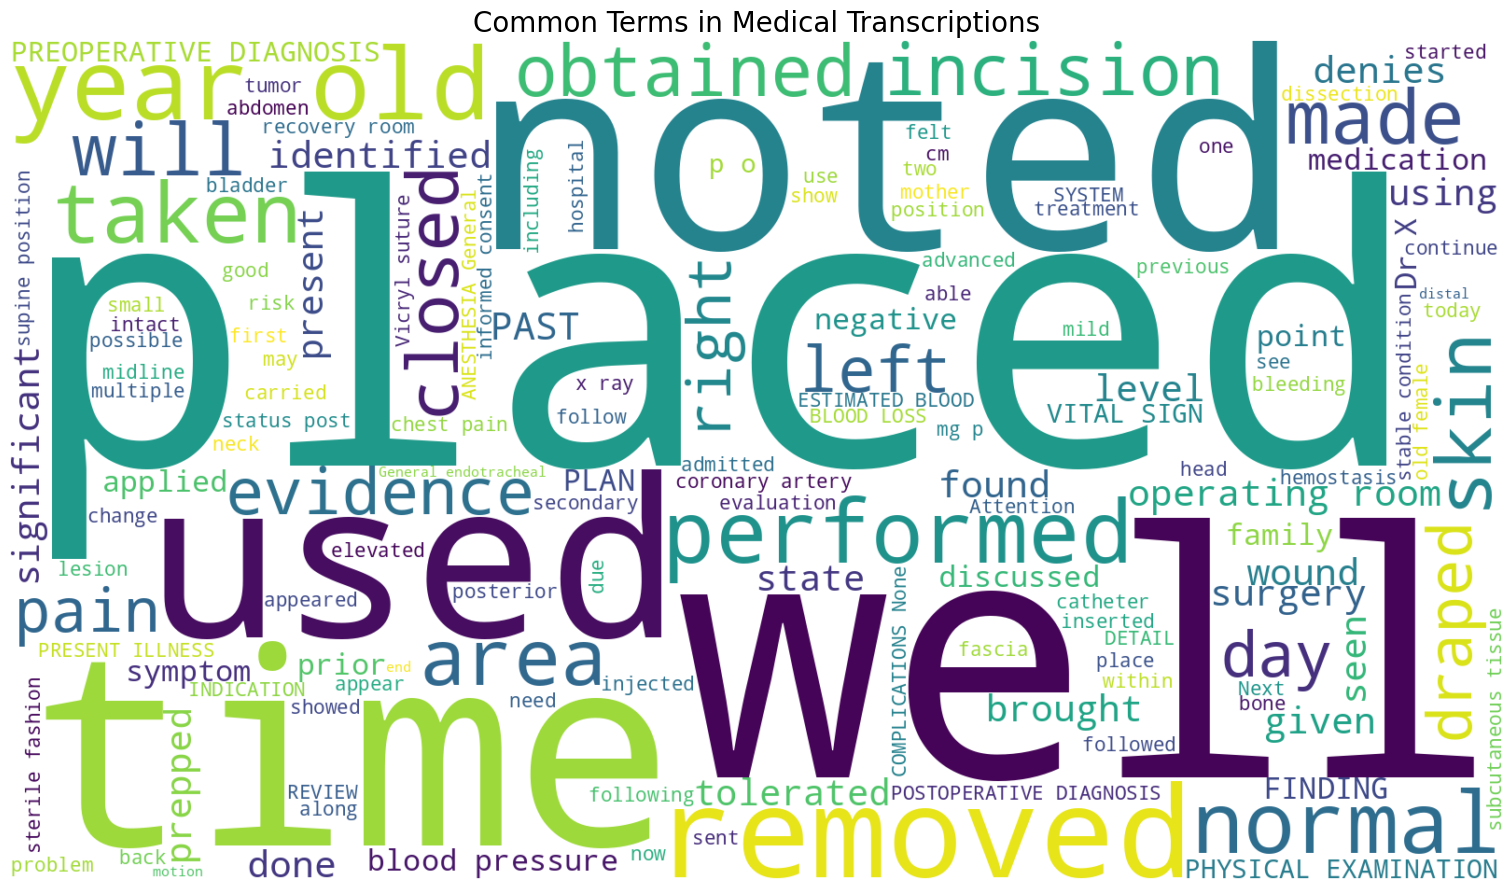

In [ ]:
custom_stopwords = set(STOPWORDS)

# Add common non-informative words if needed
custom_stopwords.update([
    "patient",
    "patients",
    "history",
    "medical",
    "procedure",
    "report"
])

wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    stopwords=custom_stopwords,
    max_words=150
).generate(all_text)

plt.figure(figsize=(16, 9))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title(
    "Common Terms in Medical Transcriptions",
    fontsize=20
)

plt.tight_layout()

plt.savefig(
    f"{eda_folder}/06_medical_transcription_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
os.listdir(eda_folder)

['04_transcription_length_distribution.png',
 '01_missing_values.png',
 '02_top10_medical_specialties.png',
 '03_complete_specialty_distribution.png',
 '05_transcription_length_by_specialty.png',
 '06_medical_transcription_wordcloud.png']

In [ ]:
import shutil

zip_path = shutil.make_archive(
    "/content/EDA_Diagrams",
    "zip",
    eda_folder
)

print("ZIP file created:", zip_path)

ZIP file created: /content/EDA_Diagrams.zip


In [ ]:
from google.colab import files

files.download("/content/EDA_Diagrams.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>